<a href="https://colab.research.google.com/github/Otza02/land2vec/blob/main/notebooks/test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Otza02/land2vec.git
%cd /content/land2vec
!pip install -e .

Cloning into 'land2vec'...
remote: Enumerating objects: 357, done.
remote: Counting objects: 100% (357/357), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 357 (delta 176), reused 285 (delta 115), pack-reused 0 (from 0)
Receiving objects: 100% (357/357), 23.75 MiB | 27.29 MiB/s, done.
Resolving deltas: 100% (176/176), done.
/content/land2vec
Obtaining file:///content/land2vec
  Preparing metadata (setup.py) ... done
  Running setup.py develop for land2vec


---Restart session before next cell---

In [2]:
%cd /content/land2vec

/content/land2vec


In [7]:
import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import lr_scheduler

import os
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
from datetime import datetime
from copy import deepcopy

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from matplotlib import pyplot as plt

from land2vec.dataset import load_data, SequenceDataset
from land2vec.config import Config
from land2vec.tokenizer import Tokenizer
from land2vec.model import GPTDecoder, run_epoch
from land2vec.utils import (
    load_config, load_model, load_train_results,
    save_config, save_model, save_train_results,
    compute_metrics, confusion_matrix, collect_predictions
    )

## load config

In [4]:
target_folder = Path(os.path.join(os.getcwd(), "models", "balanced_1"))
target_folder

PosixPath('/content/land2vec/models/balanced_1')

In [5]:
config = load_config(target_folder)
config.patience = 6
torch.manual_seed(config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.seed)
    torch.backends.cuda.enable_flash_sdp(True)
    torch.backends.cuda.enable_mem_efficient_sdp(True)
config.device

'cuda'

## load data

In [6]:
# file_path = "../data/id_seqs_text_2000_2022_chaco_santiago_frontier.zip"
file_path = Path(os.getcwd()) / "data" / "id_seqs_text_2000_2022_chaco_santiago_frontier.zip"
dataset = load_data(file_path=file_path)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(config.seed)

train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)
loader_kwargs = dict(
    batch_size=config.batch_size,
    num_workers=config.num_workers,
    pin_memory=True,
    persistent_workers=True,
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

100%|██████████| 1424457/1424457 [00:20<00:00, 70975.01it/s]


In [7]:
count = Counter(Tokenizer.VOCAB.keys())
for seq in train_dataset.dataset.encoded:
    count.update(Tokenizer.decode(seq).split("-"))
count

Counter({'[UNK]': 1,
         'A': 9961737,
         'F': 16188696,
         'G': 133703,
         'Wt': 466315,
         'U': 21095,
         'Sh': 5920939,
         'Sp': 13238,
         'B': 1,
         'Wa': 56796,
         'Nd': 1})

In [8]:
weights = torch.zeros(len(Tokenizer.VOCAB),dtype=torch.float32)

for token, freq in count.items():
    idx = Tokenizer.VOCAB[token]
    if token == "[UNK]":
        weights[idx] = 0.0
    else:
        weights[idx] = 1 / np.sqrt(freq)

# normalizar solo clases válidas
valid = weights > 0
weights[valid] /= weights[valid].mean()
weights = weights.to(config.device)
weights

tensor([0.0000e+00, 1.5647e-03, 1.2274e-03, 1.3506e-02, 7.2318e-03, 3.4001e-02,
        2.0295e-03, 4.2922e-02, 4.9384e+00, 2.0722e-02, 4.9384e+00],
       device='cuda:0')

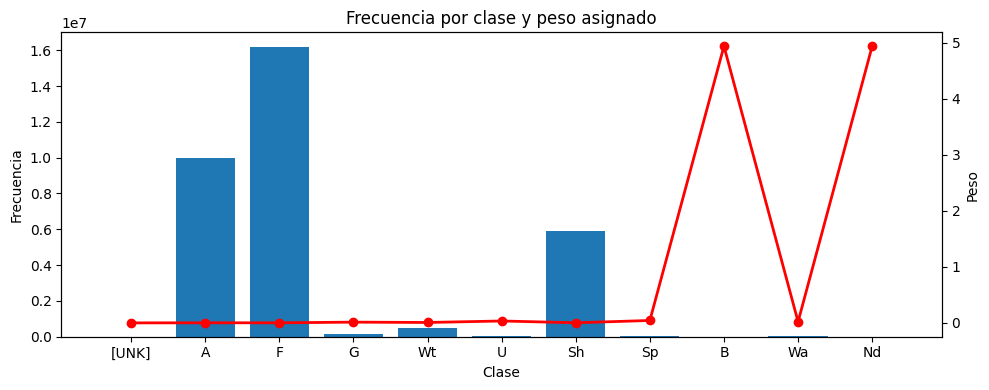

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(count.keys(), count.values(), label="frequency")
ax2.plot(count.keys(), weights.cpu().numpy(), color="red", marker="o", linewidth=2, label="Peso en la loss")

ax1.set_xlabel("Clase")
ax1.set_ylabel("Frecuencia")
ax2.set_ylabel("Peso")
ax1.set_title("Frecuencia por clase y peso asignado")
plt.tight_layout()
plt.show()

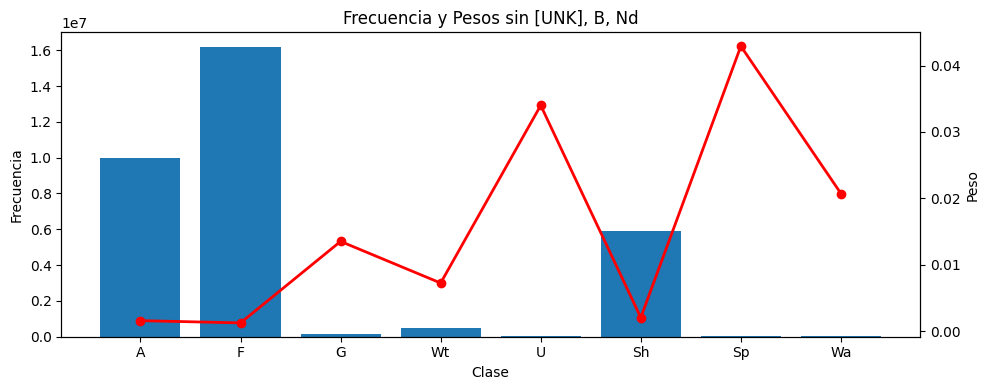

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar([k for k, v in count.items() if v > 10], [v for k, v in count.items() if v > 10], label="frequency")
ax2.plot([k for k, v in count.items() if v > 10], [w for w, v in zip(weights.cpu().numpy(), count.values()) if v > 10], color="red", marker="o", linewidth=2, label="Peso en la loss")

ax1.set_xlabel("Clase")
ax1.set_ylabel("Frecuencia")
ax2.set_ylabel("Peso")
ax1.set_title("Frecuencia y Pesos sin [UNK], B, Nd")
plt.tight_layout()
plt.show()

## create and train model

In [12]:
model = GPTDecoder(
    vocab_size=len(Tokenizer.VOCAB),
    block_size=config.block_size,
    n_embd=config.n_embd,
    n_head=config.n_head,
    n_layer=config.n_layer,
    dropout=config.dropout,
).to(config.device)

optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay, fused=config.device == "cuda")
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs, eta_min=config.min_lr)
scaler = torch.amp.GradScaler(enabled=True) if config.device == "cuda" else None

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 795,520


In [15]:
best_model_state = None
best_val_macro_f1 = -float("inf")
best_epoch = 0
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_ppl": [],
    "val_macro_f1": [],
    "accuracy": [],
    "lr": [],
    "epoch_time": [],
    "tokens_per_sec": [],
}

global_start = datetime.now()
for epoch in range(config.epochs):
    start = datetime.now()
    train_loss = run_epoch(model, train_loader, weights, optimizer, config.device, scaler, use_amp=True)
    # val_loss = run_epoch(model, val_loader, None, weights, config.device, None, use_amp=True)

    val_preds, val_true, val_loss = collect_predictions(model, val_loader, config.device, weights)
    metrics = compute_metrics(val_true, val_preds)

    if metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = metrics["macro_f1"]
        best_epoch = epoch + 1
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    epoch_seconds = (datetime.now() - start).seconds
    if epoch_seconds < 1:
        epoch_seconds = 1

    tokens_processed = (len(train_loader.dataset) * config.block_size)
    tokens_per_sec = (tokens_processed / epoch_seconds)


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_ppl"].append(torch.math.exp(val_loss))
    history["val_macro_f1"].append(metrics["macro_f1"])
    history["accuracy"].append(metrics["accuracy"])
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_seconds)
    history["tokens_per_sec"].append(tokens_per_sec)

    ppl = torch.math.exp(val_loss)
    print(
        f"[Epoch {epoch+1:03d}] | "
        f"train={train_loss:.4f} | "
        f"val={val_loss:.4f} | "
        f"ppl={ppl:.4f} | "
        f"lr={current_lr:.2e} | "
        f"time={(epoch_seconds // 60):02}:{(epoch_seconds % 60):02} | "
        f"token/s={tokens_per_sec:,.0f} | "
    )

    if patience_counter >= config.patience:
        print("Early stopping...")
        model.load_state_dict(best_model_state)
        break

total_time = (datetime.now() - global_start).seconds
print("=== Finished Training ===")
print(f"best epoch: {best_epoch}")
print(f"best val macro f1: {best_val_macro_f1:.4f}")
print(f"total training time: {total_time // 60:02}:{total_time % 60:02}")

[Epoch 001] | train=0.0828 | val=0.0614 | ppl=1.0633 | lr=9.96e-04 | time=00:41 | token/s=687,908 | 
[Epoch 002] | train=0.0619 | val=0.0602 | ppl=1.0620 | lr=9.84e-04 | time=00:39 | token/s=723,186 | 
[Epoch 003] | train=0.0616 | val=0.0599 | ppl=1.0617 | lr=9.65e-04 | time=00:39 | token/s=723,186 | 
[Epoch 004] | train=0.0615 | val=0.0601 | ppl=1.0619 | lr=9.38e-04 | time=00:40 | token/s=705,106 | 
[Epoch 005] | train=0.0614 | val=0.0599 | ppl=1.0618 | lr=9.05e-04 | time=00:40 | token/s=705,106 | 
[Epoch 006] | train=0.0613 | val=0.0598 | ppl=1.0616 | lr=8.65e-04 | time=00:41 | token/s=687,908 | 
[Epoch 007] | train=0.0613 | val=0.0600 | ppl=1.0618 | lr=8.19e-04 | time=00:41 | token/s=687,908 | 
Early stopping...
=== Finished Training ===
best epoch: 1
best val macro f1: 0.9886
total training time: 04:46


In [16]:
target_folder = Path(os.getcwd()) / "models" / "full_model"
os.makedirs(str(target_folder), exist_ok=True)
target_folder

PosixPath('/content/land2vec/models/full_model')

In [17]:
save_config(config, target_folder)
save_model(model, target_folder)
save_train_results(history, target_folder)

Config saved to /content/land2vec/models/full_model/config.json
Model saved to /content/land2vec/models/full_model/model.pt
Train data saved to /content/land2vec/models/full_model/train_data.csv


## model evaluation

In [8]:
target_folder = Path(os.getcwd()) / "models" / "full_model"
config = load_config(target_folder)
model = load_model(config, target_folder)
train_results = load_train_results(target_folder)

In [18]:
train_results = pd.DataFrame(history)

In [9]:
train_results.head()

,train_loss,val_loss,val_ppl,val_macro_f1,accuracy,lr,epoch_time,tokens_per_sec
0,0.082825,0.061412,1.063337,0.988613,0.991597,0.000996,41,687908.341463
1,0.061890,0.060155,1.062001,0.988613,0.991597,0.000984,39,723185.692308
2,0.061554,0.059866,1.061694,0.988613,0.991597,0.000965,39,723185.692308
3,0.061462,0.060080,1.061921,0.988613,0.991597,0.000938,40,705106.050000
4,0.061401,0.059945,1.061779,0.988613,0.991597,0.000905,40,705106.050000


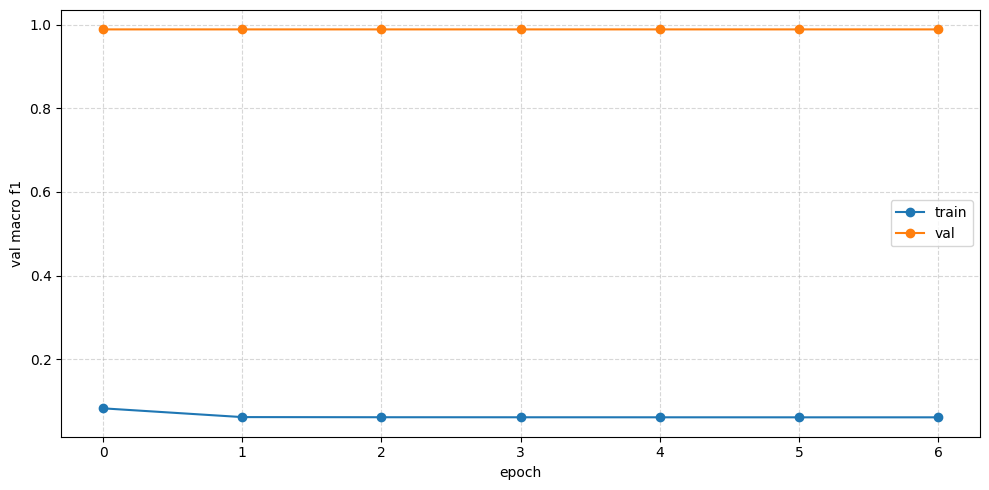

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_results["train_loss"], label="train", marker="o")
ax.plot(train_results["val_macro_f1"], label="val", marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("val macro f1")
ax.set_xticks(range(len(train_results["val_macro_f1"])))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

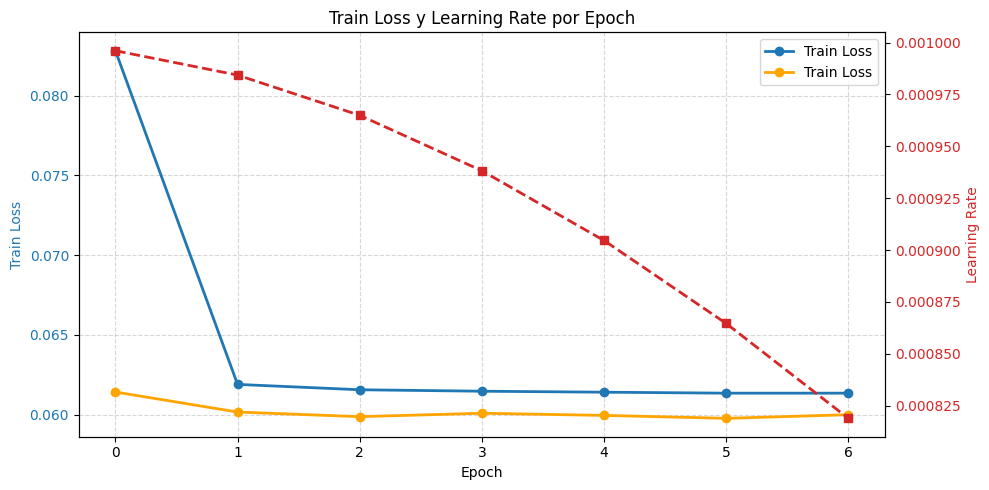

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# ----- Eje Y izquierdo (train loss) -----
color1 = 'tab:blue'

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color1)

ax1.plot(train_results["train_loss"],color=color1 ,marker='o', linewidth=2, label='Train Loss')
ax1.plot(train_results["val_loss"],color="orange" ,marker='o', linewidth=2, label='Train Loss')

ax1.tick_params(axis='y', labelcolor=color1)
ax1.legend(loc='upper right')

# ----- Eje Y derecho (learning rate) -----
ax2 = ax1.twinx()

color2 = 'tab:red'

ax2.set_ylabel('Learning Rate', color=color2)
ax2.plot(train_results["lr"], color=color2, marker='s', linestyle='--', linewidth=2, label='Learning Rate')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Train Loss y Learning Rate por Epoch')
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

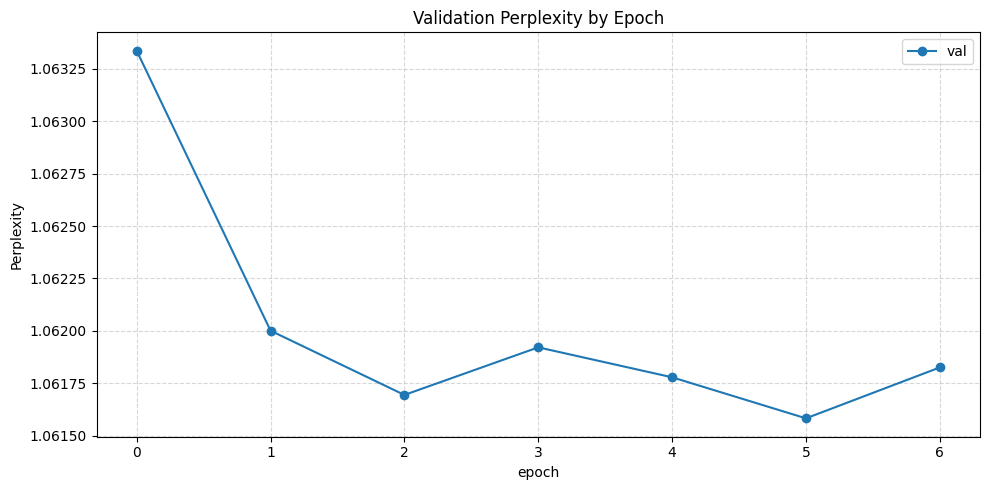

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_results["val_ppl"], label="val", marker="o")
# ax.set_ylim(1.03, 1.04)
ax.set_xlabel("epoch")
ax.set_ylabel("Perplexity")
ax.set_xticks(range(len(train_results["val_ppl"])))
ax.grid(True, linestyle='--', alpha=0.5)
plt.title("Validation Perplexity by Epoch")
plt.tight_layout()
plt.legend()
plt.show()

### prediction

In [10]:
test_dataset = load_data(file_path=Path(os.getcwd()) / "data" / "id_seqs_text_2000_2022_test_set.zip")

100%|██████████| 2487780/2487780 [00:37<00:00, 66879.77it/s]


In [13]:
loader_kwargs = dict(
    batch_size=config.batch_size,
    num_workers=config.num_workers,
    pin_memory=True,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

In [14]:
@torch.no_grad()
def predict_next(model, idx):
    model.eval()
    logits = model(idx)
    logits = logits[:, -1, :]
    probs = torch.softmax(logits, dim=-1)
    pred = logits.argmax(dim=-1)
    return pred, probs

@torch.no_grad()
def next_token_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()
    return correct / total

@torch.no_grad()
def accuracy_by_position(model, loader, device):
    model.eval()
    acc_sum = 0.0
    batches = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=-1)
        correct = (preds == y).float()
        pos_acc = correct.mean(dim=0)
        acc_sum += pos_acc
        batches += 1
    return (acc_sum / batches).cpu()

In [15]:
next_token_accuracy(model, test_loader, config.device)

0.9921693053828934

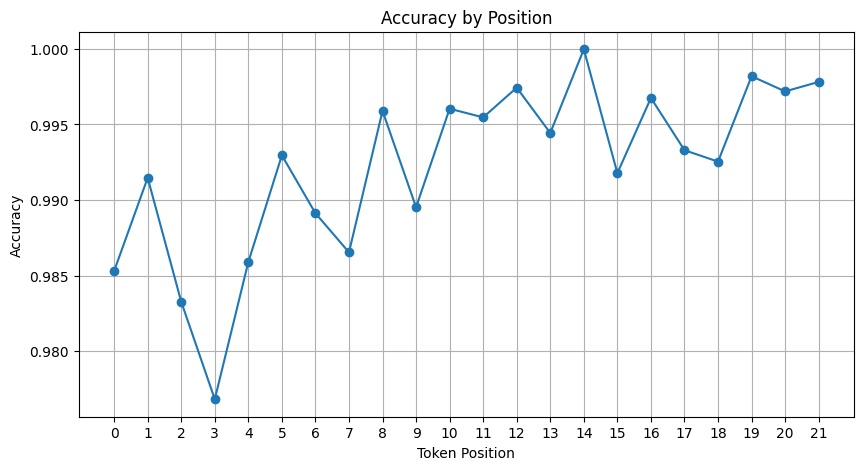

In [16]:
pos_acc = accuracy_by_position(model, test_loader, config.device)
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(pos_acc, marker="o")
ax.set_xticks(range(config.block_size))
ax.set_xlabel("Token Position")
ax.set_ylabel("Accuracy")
plt.title("Accuracy by Position")
plt.grid(True)
plt.show()

In [17]:
weights = torch.tensor([0.0000e+00, 1.5647e-03, 1.2274e-03, 1.3506e-02, 7.2318e-03, 3.4001e-02,
        2.0295e-03, 4.2922e-02, 4.9384e+00, 2.0722e-02, 4.9384e+00])
weights = weights.to(config.device)
weights

tensor([0.0000e+00, 1.5647e-03, 1.2274e-03, 1.3506e-02, 7.2318e-03, 3.4001e-02,
        2.0295e-03, 4.2922e-02, 4.9384e+00, 2.0722e-02, 4.9384e+00],
       device='cuda:0')

In [20]:
model.eval()
all_preds, all_targets, val_loss = collect_predictions(model, test_loader, config.device, weights, max_batches=200)
metrics = compute_metrics(all_targets, all_preds)

In [21]:
print(f"Accuracy: {metrics["accuracy"]:.4f}")
print(f"Macro f1: {metrics["macro_f1"]:.4f}")

Accuracy: 0.9960
Macro f1: 0.9789


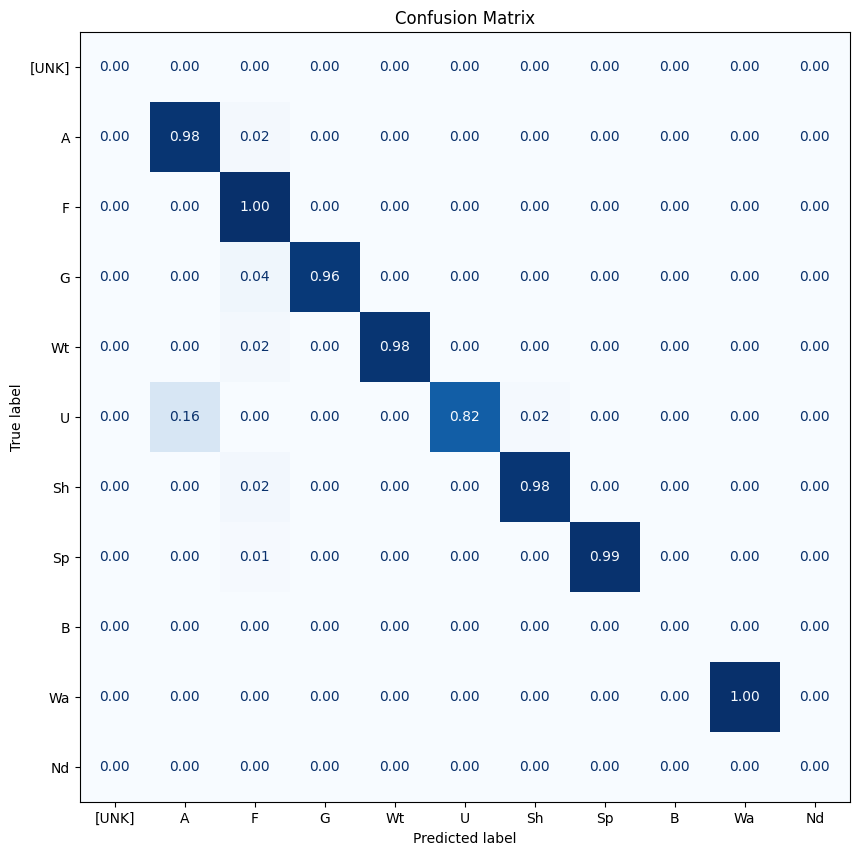

In [22]:
valid_ids = sorted(Tokenizer.REVERSE_VOCAB.keys())

cm = confusion_matrix(all_targets, all_preds, labels=valid_ids, normalize="true")

labels = [Tokenizer.REVERSE_VOCAB[i] for i in valid_ids]

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
ax.grid(False)
disp.ax_.set_title("Confusion Matrix")
plt.show()